# 04-A · Fatigue Connectome Baselines — Adversarial Audit

**Purpose** — Evaluate whether resting-state functional connectivity can classify post-COVID **fatigue** using simple, interpretable baselines before any representation learning.

**Scientific role** — This is the **main narrative notebook** for baseline evidence quality. It is intentionally conservative. Technical stress tests are delegated to `04_b`.

## Two Binary Targets (tested in parallel)

| Target | Positive class | Negative class | Restriction | Role |
|--------|---------------|----------------|-------------|------|
| **D** | FATIGA EXTREMA | NO HAY FATIGA | COVID-only | **Primary** fatigue contrast |
| **E** | FATIGA EXTREMA | NO HAY FATIGA ∪ healthy CONTROLS | All groups | **Shortcut / falsification audit only** |

## Interpretation Rules (read before results)

1. **Only Target D can support a fatigue-biomarker claim.**
2. **Target E cannot support fatigue biology by itself.** If E exceeds D, default interpretation is shortcut learning.
3. **All four criteria are required for `CAUTIOUS GO`:**
   - (a) Target D best residualized channel survives **FWER-style channel-selection correction**: `max-perm p < 0.05`.
   - (b) Female-only sensitivity confirms direction: at least one channel with `perm p < 0.10`.
   - (c) Incremental value over Age+Sex is significant: bootstrap `ΔAUC p < 0.05`.
   - (d) Sex-prediction AUC from same features remains `< 0.70`.
4. **BH/FDR q-values are exploratory here.** BH survival without max-perm survival is not sufficient for `CAUTIOUS GO`.
5. **Verdict hierarchy:**
   - If criterion (a) fails → `INDETERMINATE` (or null) regardless of BH.
   - If criterion (a) passes but (b) or (c) fails → `INDETERMINATE`.
   - Only if all (a)-(d) pass → `CAUTIOUS GO`.

---
*Generated by `scripts/run_fatigue_connectome_baselines.py`.*
*Audit criteria hardened v2 — updated 2026-03-15.*


In [1]:
# Environment assumed pre-configured.
# Run from the project root with the project virtual environment active.


In [2]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from betavae_xai.analysis_qc.notebook_utils import (
    set_publication_style, save_figure, create_color_palette,
)

# Base style from project utilities + conservative publication tweaks.
set_publication_style("notebook")
sns.set_context("paper", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlepad": 8,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
})

OUT = PROJECT_ROOT / "results" / "fatigue_connectome_baselines"
TABLES = OUT / "Tables"
FIGS = OUT / "Figures"
FIGS.mkdir(parents=True, exist_ok=True)

# Load precomputed artifacts from the baseline script.
df_base = pd.read_csv(TABLES / "all_baseline_results.csv")
df_diag = pd.read_csv(TABLES / "all_diagnostic_results.csv")
df_preds = pd.read_csv(TABLES / "all_subject_predictions.csv")
dec = pd.read_csv(TABLES / "stop_go_decision_table.csv")
cross = (TABLES / "cross_target_interpretation.txt").read_text().strip()

with open(OUT / "Logs" / "run_config.json") as f:
    run_cfg = json.load(f)
is_smoke = run_cfg.get("smoke_test", False)

print(f"Loaded {len(df_base)} baseline rows, {len(df_diag)} diagnostic rows")
print(f"Smoke test: {is_smoke}")
print(f"Permutations: {run_cfg.get('n_permutations')}")


Loaded 44 baseline rows, 21 diagnostic rows
Smoke test: False
Permutations: 1000


## §1 — Target Definitions & Sample Sizes

In [3]:
for tgt in ["D", "E"]:
    fp = TABLES / f"target_{tgt}_definition.json"
    if fp.exists():
        info = json.loads(fp.read_text())
        print(f"\n{'='*50}")
        print(f"TARGET {tgt}: {info['desc']}")
        print(f"  n = {info['n_total']}  ({info['n_pos']} pos / {info['n_neg']} neg)")
        print(f"  prevalence = {info['prevalence']:.2%}")
        if "WARNING" in info:
            print(f"  ⚠️  {info['WARNING']}")



TARGET D: FATIGA EXTREMA vs NO HAY FATIGA  (COVID-only)
  n = 53  (29 pos / 24 neg)
  prevalence = 54.72%

TARGET E: FATIGA EXTREMA vs NO HAY FATIGA  (all groups)
  n = 85  (31 pos / 54 neg)
  prevalence = 36.47%
  ⚠️  Target E is NOT a pure fatigue classifier. Positive class is ≈94 % COVID while Negative is ≈44 % COVID. Any classifier may exploit the COVID-vs-CONTROL shortcut. Controls with intermediate FATIGA are excluded.


## §2 — Confound Audit

**Critical confounds identified:**

- **Sex (Target D):** chi-square p = 0.025, with marked class imbalance (about 79% female in positives vs 46% in negatives). Metadata alone therefore has **modest but non-trivial** predictive value (AUC about 0.64, p about 0.03 in this cohort).
- **Group (Target E):** chi-square p = 2 x 10^-5, indicating strong COVID/CONTROL composition imbalance.

For consistency, narrative sections use rounded values (for readability), while section 8 reports exact hardening values.


Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig1_confound_audit.png


Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig1_confound_audit.pdf


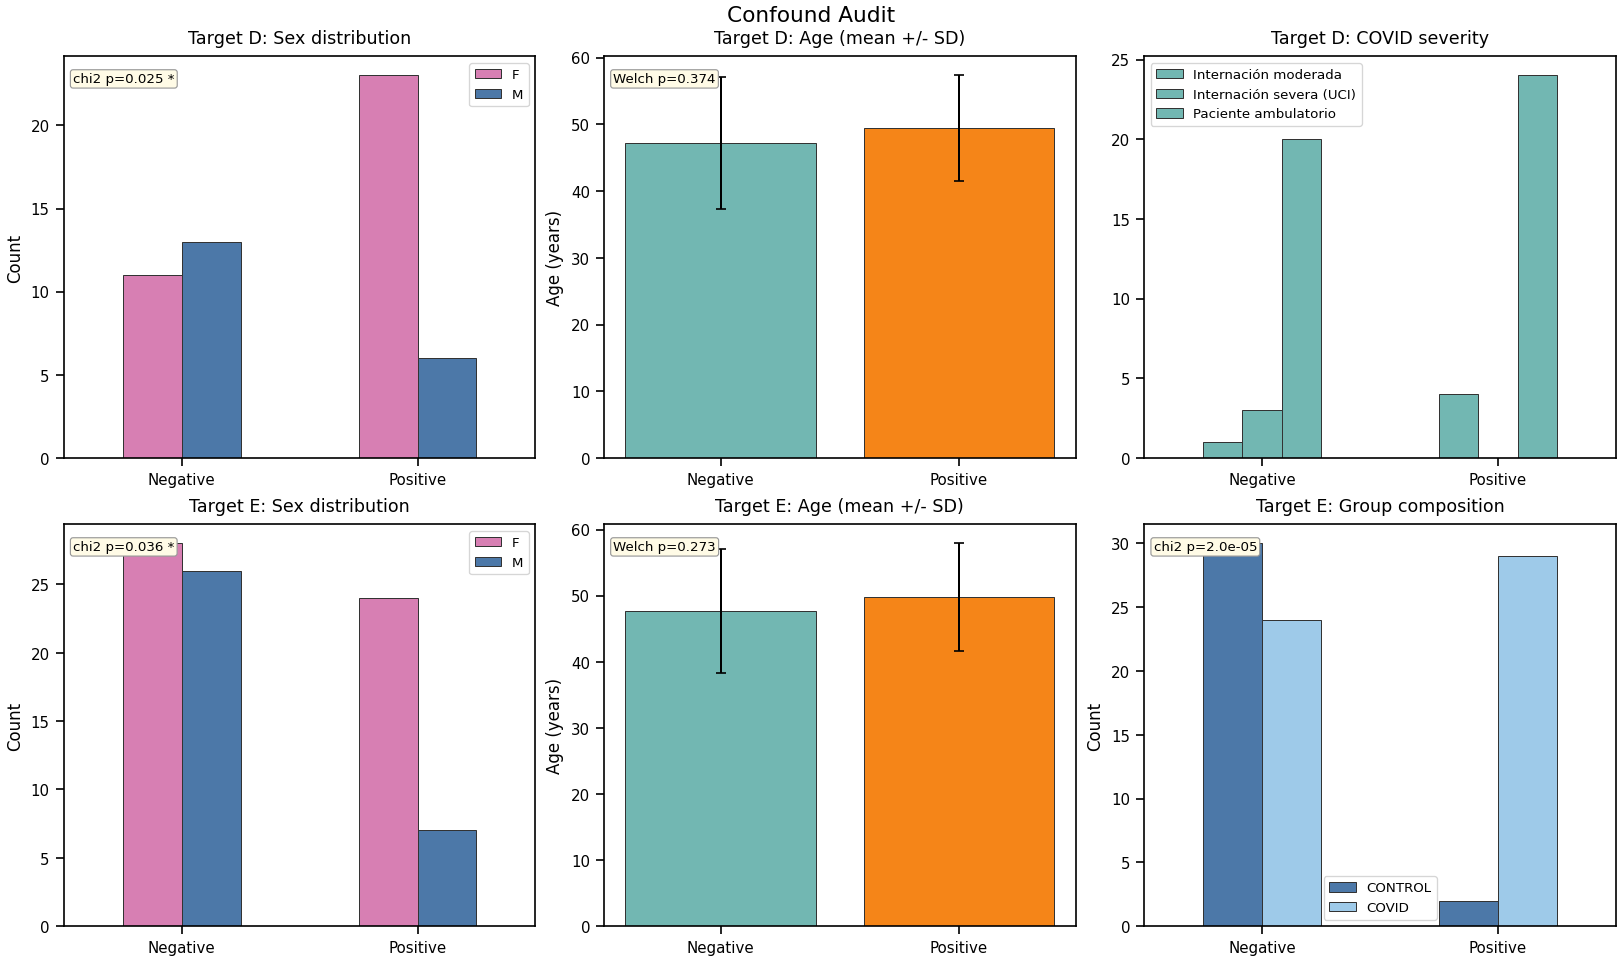

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.8), constrained_layout=True)

sex_palette = ["#d77fb3", "#4c78a8"]
age_palette = ["#72b7b2", "#f58518"]
grp_palette = ["#4c78a8", "#9ecae9", "#f58518", "#e45756"]

for row, tgt in enumerate(["D", "E"]):
    # Sex counts
    ax = axes[row, 0]
    fp = TABLES / f"confound_{tgt}_sex_counts.csv"
    if fp.exists():
        sex = pd.read_csv(fp, index_col=0)
        sex.plot.bar(ax=ax, color=sex_palette[: sex.shape[1]], edgecolor="#333333", linewidth=0.6)
        ax.set_title(f"Target {tgt}: Sex distribution", fontsize=10.5)
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)

        chi2_fp = TABLES / f"confound_{tgt}_sex_chi2.csv"
        if chi2_fp.exists():
            chi2s = pd.read_csv(chi2_fp, index_col=0, header=None).squeeze()
            p = float(chi2s.loc["p"])
            ax.text(
                0.02,
                0.96,
                f"chi2 p={p:.3f}" + (" *" if p < 0.05 else ""),
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="#fffbe6", ec="#999999", lw=0.7),
            )

    # Age distribution summary
    ax = axes[row, 1]
    fp = TABLES / f"confound_{tgt}_age_desc.csv"
    if fp.exists():
        age = pd.read_csv(fp, index_col=0)
        if "mean" in age.columns and "std" in age.columns:
            means = age["mean"].values.astype(float)
            stds = age["std"].values.astype(float)
            ax.bar(age.index, means, yerr=stds, capsize=3, color=age_palette[: len(means)], edgecolor="#333333", linewidth=0.6)
            ax.set_title(f"Target {tgt}: Age (mean +/- SD)", fontsize=10.5)
            ax.set_ylabel("Age (years)")
            ax.tick_params(axis="x", rotation=0)

            ttest_fp = TABLES / f"confound_{tgt}_age_ttest.csv"
            if ttest_fp.exists():
                tts = pd.read_csv(ttest_fp, index_col=0, header=None).squeeze()
                p = float(tts.loc["p"])
                ax.text(
                    0.02,
                    0.96,
                    f"Welch p={p:.3f}",
                    transform=ax.transAxes,
                    ha="left",
                    va="top",
                    fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", fc="#fffbe6", ec="#999999", lw=0.7),
                )

    # Group/Severity counts
    ax = axes[row, 2]
    grp_fp = TABLES / f"confound_{tgt}_group_counts.csv"
    sev_fp = TABLES / f"confound_{tgt}_severity_counts.csv"
    if grp_fp.exists():
        grp = pd.read_csv(grp_fp, index_col=0)
        colors = grp_palette[: grp.shape[1]]
        grp.plot.bar(ax=ax, color=colors, edgecolor="#333333", linewidth=0.6)
        ax.set_title(f"Target {tgt}: Group composition", fontsize=10.5)
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)

        chi2g_fp = TABLES / f"confound_{tgt}_group_chi2.csv"
        if chi2g_fp.exists():
            chi2gs = pd.read_csv(chi2g_fp, index_col=0, header=None).squeeze()
            pg = float(chi2gs.loc["p"])
            ax.text(
                0.02,
                0.96,
                f"chi2 p={pg:.1e}" if pg < 1e-3 else f"chi2 p={pg:.3f}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="#fffbe6", ec="#999999", lw=0.7),
            )
    elif sev_fp.exists():
        sev = pd.read_csv(sev_fp, index_col=0)
        sev.plot.bar(ax=ax, color="#72b7b2", edgecolor="#333333", linewidth=0.6)
        ax.set_title(f"Target {tgt}: COVID severity", fontsize=10.5)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)
    else:
        ax.text(0.5, 0.5, "N/A (single group)", transform=ax.transAxes, ha="center", va="center", fontsize=9, color="#666666")
        ax.set_title(f"Target {tgt}: Group composition", fontsize=10.5)

fig.suptitle("Confound Audit", fontsize=13, y=1.02)
save_figure(fig, str(FIGS / "fig1_confound_audit"), formats=["png", "pdf"])
plt.show()


## §3 — Baseline AUC Comparison (NOMINAL / EXPLORATORY LAYER)

> ⚠️ **Exploratory layer only.** Single-channel nominal permutation p-values are shown for provenance and are **not** multiplicity-corrected.
> Authoritative interpretation is in §8.

Bars show cross-validated AUC (dashed vertical line at 0.5 = chance).
Asterisk marks nominal p < 0.05 for that channel (uncorrected across 7 channels).


Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig2_baseline_auc_comparison.png
Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig2_baseline_auc_comparison.pdf


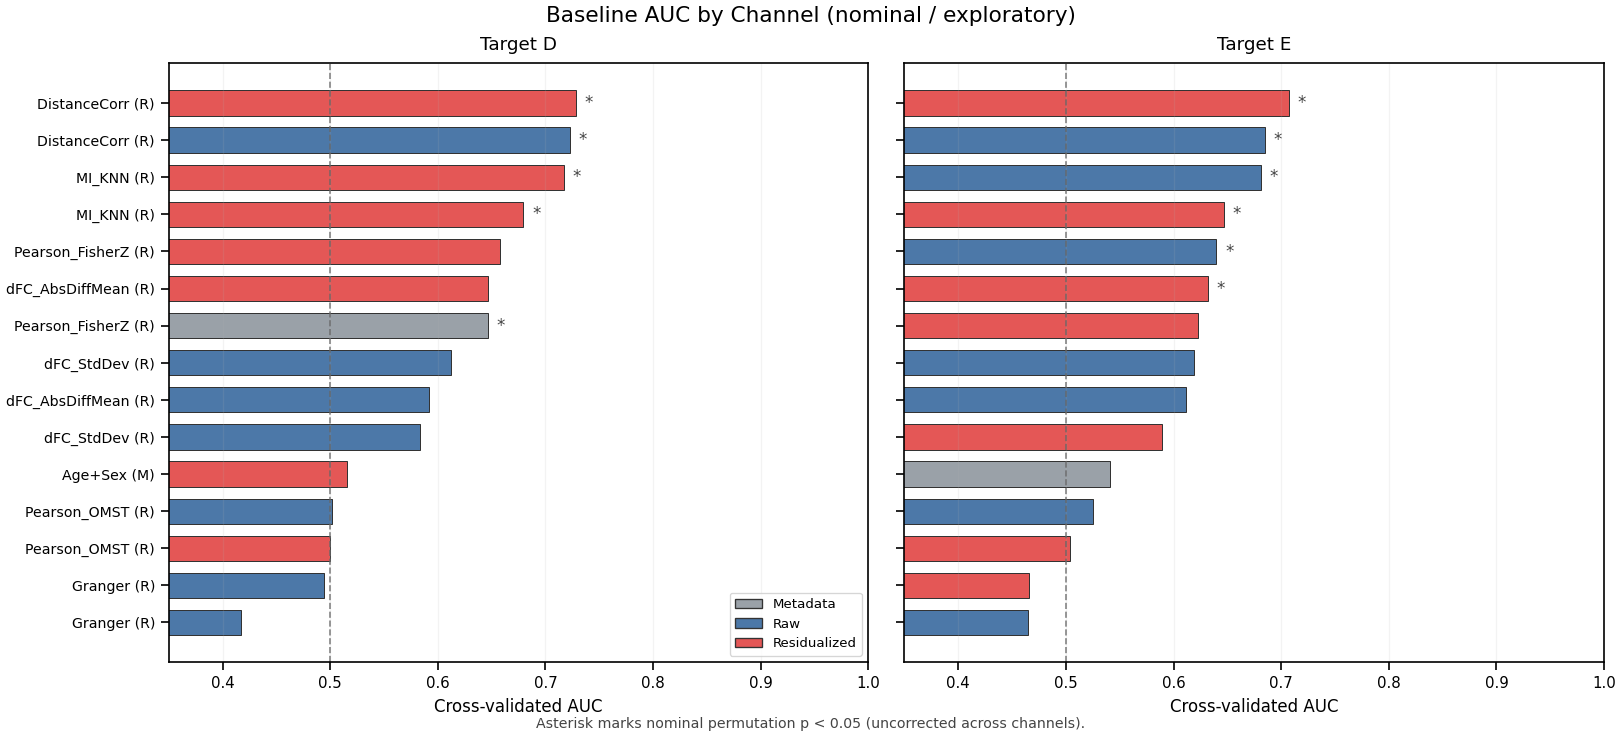

In [5]:
# Prepare data for plotting
plot_data = df_base[~df_base["label"].str.contains("female")].copy()
plot_data["kind"] = plot_data["label"].apply(
    lambda x: "Metadata" if x.startswith("metadata") else ("Raw" if x.startswith("raw_") else "Residualized")
)
plot_data["short"] = plot_data["label"].apply(
    lambda x: "Age+Sex" if x.startswith("metadata") else x.split("_", 2)[-1] if "_" in x else x
)

kind_colors = {"Metadata": "#9aa1a8", "Raw": "#4c78a8", "Residualized": "#e45756"}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0), sharey=True, constrained_layout=True)

for col, tgt in enumerate(["D", "E"]):
    ax = axes[col]
    td = plot_data[plot_data["target"] == tgt].sort_values("auc_cv", ascending=True).reset_index(drop=True)

    y_pos = np.arange(len(td))
    colors = [kind_colors.get(k, "#555555") for k in td["kind"]]
    ax.barh(y_pos, td["auc_cv"], color=colors, edgecolor="#333333", linewidth=0.6, height=0.68)

    for i, r in td.iterrows():
        if pd.notna(r.get("perm_p")) and float(r["perm_p"]) < 0.05:
            ax.text(float(r["auc_cv"]) + 0.008, i, "*", fontsize=10, va="center", color="#444444")

    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{r['short']} ({r['kind'][0]})" for _, r in td.iterrows()], fontsize=8.5)
    ax.axvline(0.5, color="#666666", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.set_xlim(0.35, 1.0)
    ax.set_xlabel("Cross-validated AUC")
    ax.set_title(f"Target {tgt}", fontsize=11)
    ax.grid(axis="x", alpha=0.15)

    if col == 0:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=c, edgecolor="#333333", label=k) for k, c in kind_colors.items()]
        ax.legend(handles=legend_elements, loc="lower right", frameon=True)

fig.suptitle("Baseline AUC by Channel (nominal / exploratory)", fontsize=13)
fig.text(0.5, -0.01, "Asterisk marks nominal permutation p < 0.05 (uncorrected across channels).", ha="center", fontsize=8.5, color="#444444")
save_figure(fig, str(FIGS / "fig2_baseline_auc_comparison"), formats=["png", "pdf"])
plt.show()


## §4 — Permutation Null Assessment (NOMINAL / EXPLORATORY LAYER)

> ⚠️ **Nominal single-channel p-values only.** These values are not corrected for channel-selection multiplicity.
> Section 8 provides the corrected hard-gate interpretation.

This panel indicates nominal departures from the permutation null (p < 0.05) and should be read as necessary-but-not-sufficient evidence.


Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig3_permutation_pvalues.png
Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig3_permutation_pvalues.pdf


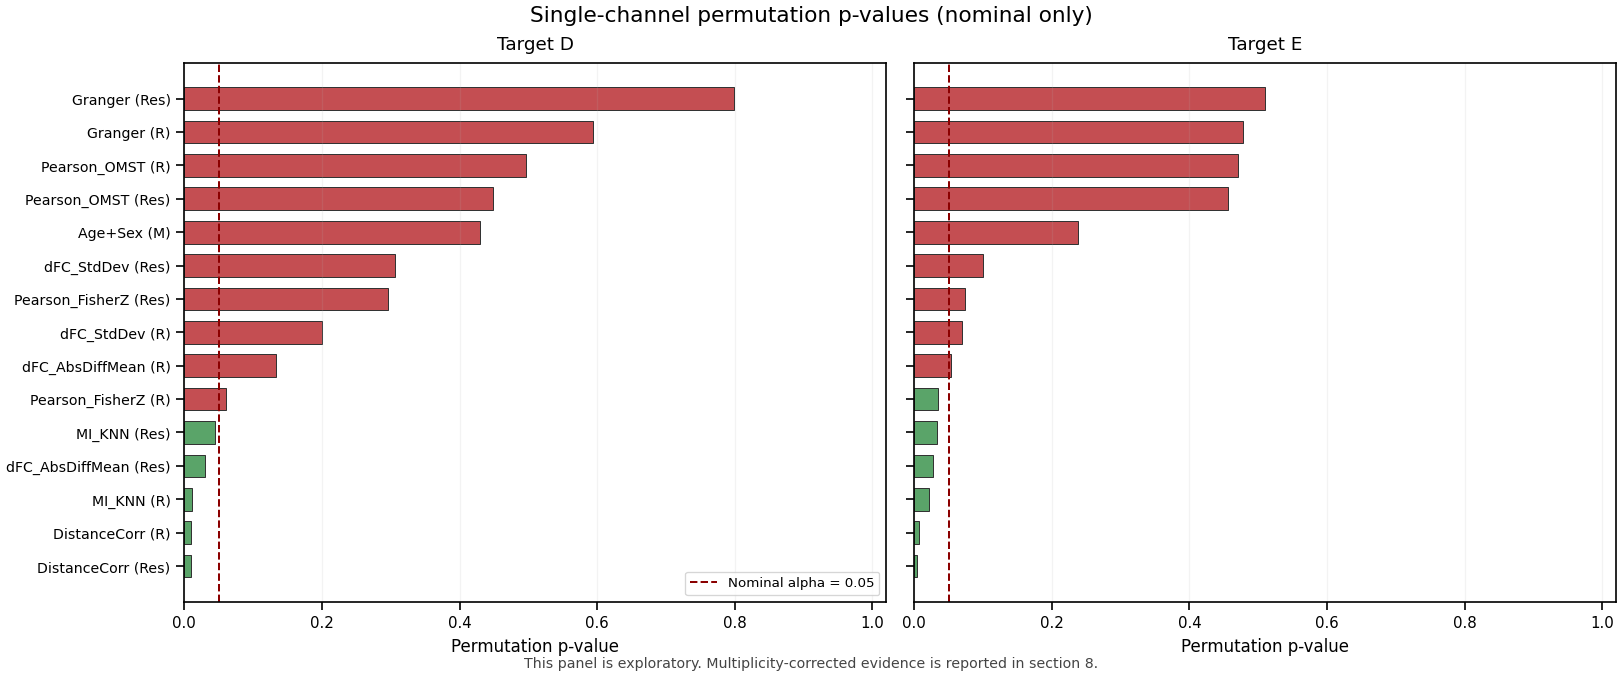

In [6]:
perm_data = df_base[df_base["perm_p"].notna() & ~df_base["label"].str.contains("female")].copy()
perm_data["short"] = perm_data["label"].apply(
    lambda x: "Age+Sex" if x.startswith("metadata") else x.split("_", 2)[-1]
)
perm_data["kind"] = perm_data["label"].apply(
    lambda x: "M" if x.startswith("metadata") else ("R" if x.startswith("raw_") else "Res")
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5), sharey=True, constrained_layout=True)

for col, tgt in enumerate(["D", "E"]):
    ax = axes[col]
    td = perm_data[perm_data["target"] == tgt].sort_values("perm_p").reset_index(drop=True)

    y_pos = np.arange(len(td))
    colors = ["#5aa469" if float(p) < 0.05 else "#c44e52" for p in td["perm_p"]]
    ax.barh(y_pos, td["perm_p"], color=colors, edgecolor="#333333", linewidth=0.6, height=0.68)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{r['short']} ({r['kind']})" for _, r in td.iterrows()], fontsize=8.5)
    ax.axvline(0.05, color="#8b0000", linestyle="--", linewidth=1.2, label="Nominal alpha = 0.05")
    ax.set_xlim(0, 1.02)
    ax.set_xlabel("Permutation p-value")
    ax.set_title(f"Target {tgt}", fontsize=11)
    ax.grid(axis="x", alpha=0.15)

    if col == 0:
        ax.legend(loc="lower right", frameon=True)

fig.suptitle("Single-channel permutation p-values (nominal only)", fontsize=13)
fig.text(0.5, -0.01, "This panel is exploratory. Multiplicity-corrected evidence is reported in section 8.", ha="center", fontsize=8.5, color="#444444")
save_figure(fig, str(FIGS / "fig3_permutation_pvalues"), formats=["png", "pdf"])
plt.show()


## §5 — Shortcut / Confound Diagnostics

**Sex-prediction AUC** — If the same PCA features can predict sex with
high AUC, the fatigue signal may be confounded with sex.

**Group-prediction AUC** (Target E only) — If features easily
discriminate COVID from CONTROL, any fatigue classification may be
a group shortcut, not a fatigue biomarker.

> **Interpretation cutoffs:**
> - Sex AUC > 0.70 → features heavily encode sex → high confound risk
> - Group AUC > 0.65 → features discriminate groups → shortcut threat


Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig4_confound_diagnostics.png
Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig4_confound_diagnostics.pdf


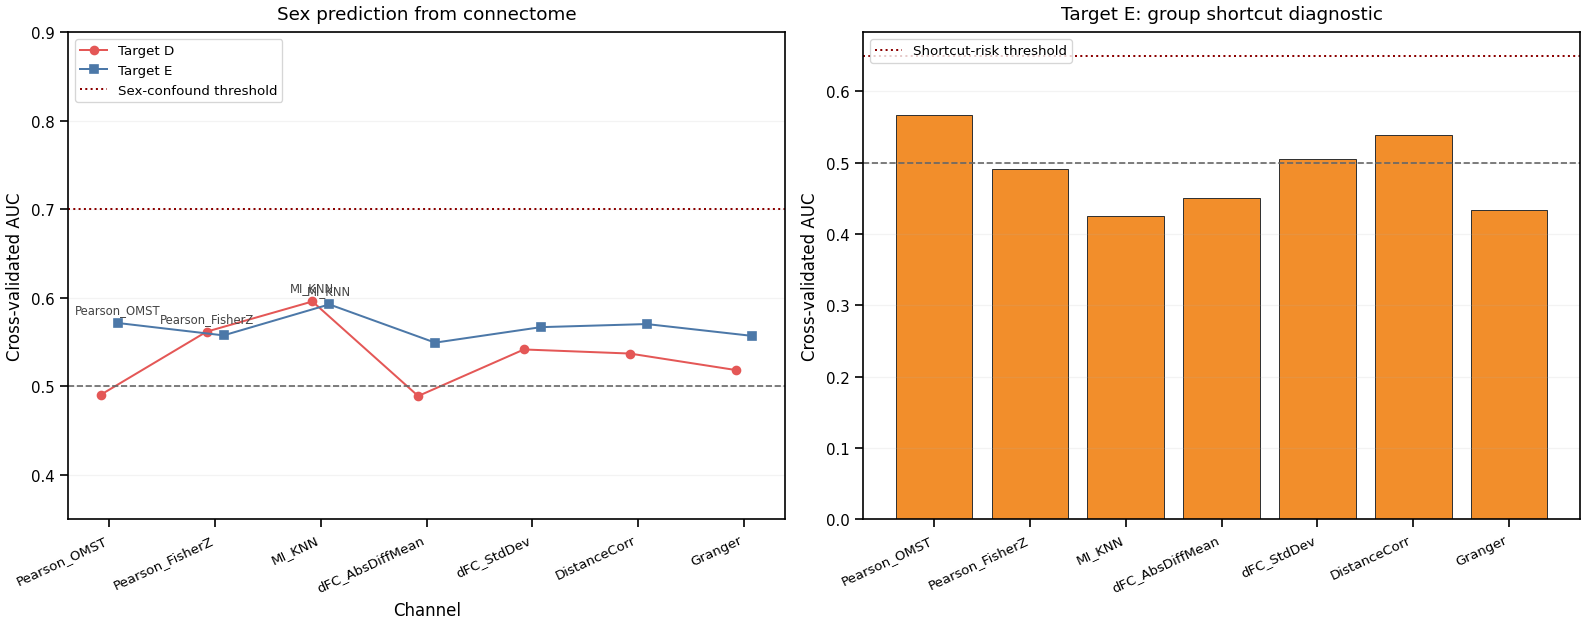

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)

# Panel A: Sex diagnostic
ax = axes[0]
sex_diag = df_diag[df_diag["label"].str.startswith("sex_diag")].copy()

if len(sex_diag) > 0:
    # Use explicit channel index when available so x coordinates are stable.
    if "channel_idx" in sex_diag.columns:
        sex_diag["x"] = sex_diag["channel_idx"].astype(int)
    else:
        sex_diag = sex_diag.sort_values(["target", "channel_name"], kind="stable").reset_index(drop=True)
        sex_diag["x"] = sex_diag.groupby("target").cumcount()

    for tgt, marker, color, dx in [("D", "o", "#e45756", -0.08), ("E", "s", "#4c78a8", 0.08)]:
        td = sex_diag[sex_diag["target"] == tgt].copy().sort_values("x")
        if len(td) == 0:
            continue

        x = td["x"].to_numpy(dtype=float) + dx
        y = td["auc_cv"].to_numpy(dtype=float)
        ax.plot(x, y, marker=marker, color=color, linewidth=1.2, markersize=4.8, label=f"Target {tgt}")

        # Sparse annotation: top-2 channels by AUC per target.
        top_td = td.nlargest(2, "auc_cv")
        for _, r in top_td.iterrows():
            xr = float(r["x"]) + dx
            yr = float(r["auc_cv"])
            ch = r.get("channel_name", "?")
            ax.annotate(
                ch,
                (xr, yr),
                textcoords="offset points",
                xytext=(0, 6),
                ha="center",
                fontsize=7,
                color="#444444",
            )

    if "channel_idx" in sex_diag.columns:
        ch_ticks = sorted(sex_diag["x"].unique())
        ch_labels = []
        for t in ch_ticks:
            sub = sex_diag[sex_diag["x"] == t]
            label = sub["channel_name"].iloc[0] if len(sub) and "channel_name" in sub else str(t)
            ch_labels.append(label)
        ax.set_xticks(ch_ticks)
        ax.set_xticklabels(ch_labels, rotation=25, ha="right", fontsize=8)
        ax.set_xlabel("Channel")
    else:
        ax.set_xlabel("Channel index")

ax.axhline(0.5, color="#666666", linestyle="--", linewidth=1.0)
ax.axhline(0.7, color="#8b0000", linestyle=":", linewidth=1.2, label="Sex-confound threshold")
ax.set_ylabel("Cross-validated AUC")
ax.set_title("Sex prediction from connectome", fontsize=11)
ax.set_ylim(0.35, 0.9)
ax.grid(axis="y", alpha=0.15)
ax.legend(loc="upper left", frameon=True)

# Panel B: Group diagnostic (Target E)
ax = axes[1]
grp_diag = df_diag[df_diag["label"].str.startswith("group_diag")].copy()
if len(grp_diag) > 0:
    td = grp_diag[grp_diag["target"] == "E"].reset_index(drop=True)
    if len(td) > 0:
        x = np.arange(len(td))
        ax.bar(x, td["auc_cv"], color="#f28e2b", edgecolor="#333333", linewidth=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels([r.get("channel_name", "?") for _, r in td.iterrows()], fontsize=8, rotation=25, ha="right")

    ax.axhline(0.5, color="#666666", linestyle="--", linewidth=1.0)
    ax.axhline(0.65, color="#8b0000", linestyle=":", linewidth=1.2, label="Shortcut-risk threshold")
    ax.set_ylabel("Cross-validated AUC")
    ax.set_title("Target E: group shortcut diagnostic", fontsize=11)
    ax.grid(axis="y", alpha=0.15)
    ax.legend(loc="upper left", frameon=True)

    if len(td) > 0 and (td["auc_cv"] > 0.65).any():
        ax.text(
            0.02,
            0.95,
            "Target E shows strong group separability\n(shortcut risk)",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="#fffbe6", ec="#999999", lw=0.7),
        )
else:
    ax.text(0.5, 0.5, "No group diagnostic available", transform=ax.transAxes, ha="center", va="center", fontsize=10, color="#666666")
    ax.set_title("Target E: group shortcut diagnostic", fontsize=11)

save_figure(fig, str(FIGS / "fig4_confound_diagnostics"), formats=["png", "pdf"])
plt.show()


## §6 — Female-Only Sensitivity Analysis

This panel compares **female-only runs** against the corresponding **all-subject raw-channel baselines** (same channel, same target), so the comparison is descriptive and channel-matched.

Interpretation intent:
- If signal persists in female-only data, sex-confound concern is reduced.
- If signal weakens/collapses, sex-imbalance sensitivity is plausible, but not conclusive by itself.

> **Power caveat:** The female-only subset for Target D has n = 34 (23 pos / 11 neg), which is severely underpowered. A non-significant female-only result is therefore **non-confirmatory**, not definitive falsification.


Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig5_female_only_sensitivity.png
Saved: /home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines/Figures/fig5_female_only_sensitivity.pdf


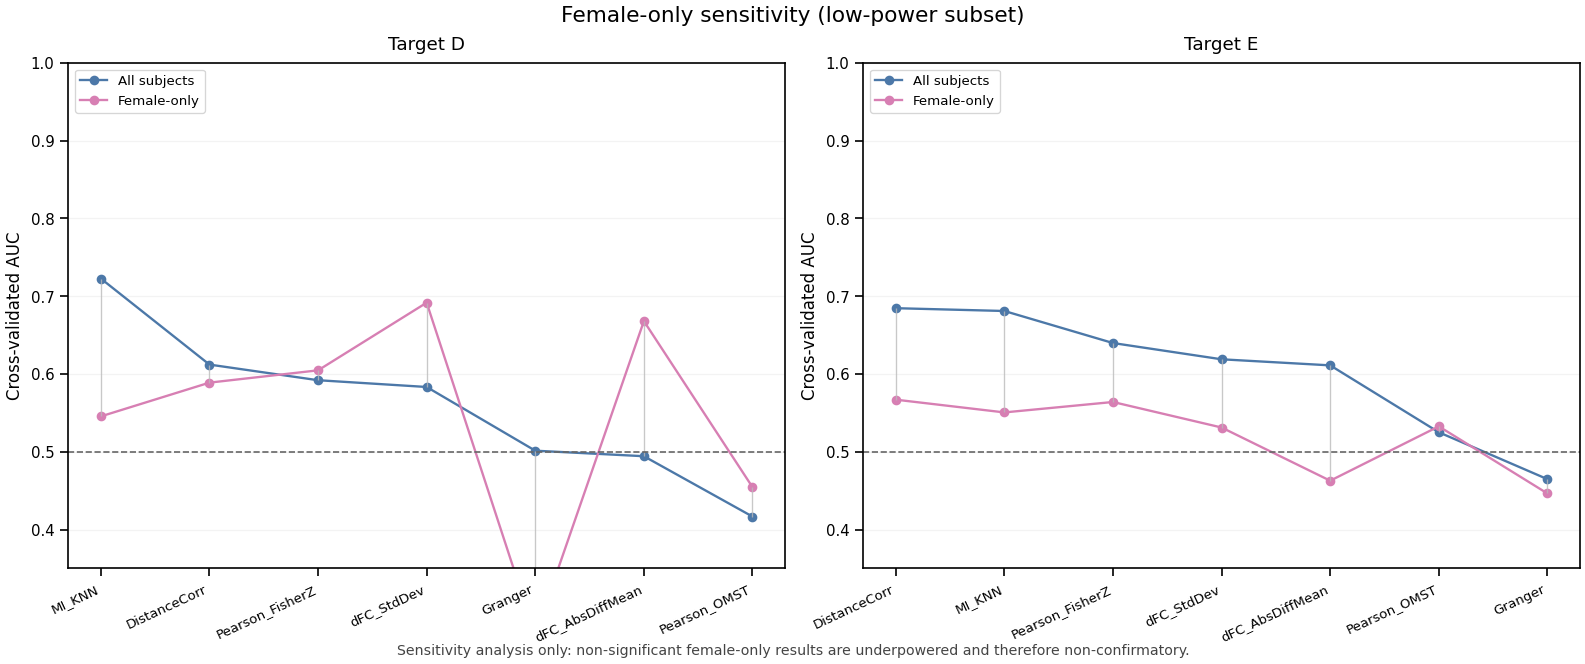

In [8]:
fem = df_base[df_base["label"].str.startswith("female")].copy()
if len(fem) > 0:
    fem["ch_name"] = fem["label"].apply(lambda x: x.split("_", 2)[-1] if "_" in x else x)

    raw = df_base[df_base["label"].str.startswith("raw_")].copy()
    raw["ch_name"] = raw["label"].apply(lambda x: x.split("_", 2)[-1] if "_" in x else x)

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.4), constrained_layout=True)
    for col, tgt in enumerate(["D", "E"]):
        ax = axes[col]
        fd = fem[fem["target"] == tgt]
        rd = raw[raw["target"] == tgt]

        if len(fd) > 0:
            merged = fd.merge(
                rd[["target", "ch_name", "auc_cv"]],
                on=["target", "ch_name"],
                suffixes=("_female", "_all"),
            ).sort_values("auc_cv_all", ascending=False)

            if len(merged) > 0:
                x = np.arange(len(merged))
                ax.plot(x, merged["auc_cv_all"], marker="o", color="#4c78a8", linewidth=1.4, label="All subjects")
                ax.plot(x, merged["auc_cv_female"], marker="o", color="#d77fb3", linewidth=1.4, label="Female-only")
                ax.vlines(x, merged["auc_cv_female"], merged["auc_cv_all"], color="#bbbbbb", linewidth=0.8, alpha=0.8)

                ax.set_xticks(x)
                ax.set_xticklabels(merged["ch_name"], fontsize=8, rotation=25, ha="right")

                # Subtle marker for female-only nominal hits.
                for i, (_, r) in enumerate(merged.iterrows()):
                    fp_val = fd[fd["ch_name"] == r["ch_name"]]["perm_p"]
                    if len(fp_val) > 0 and pd.notna(fp_val.iloc[0]) and float(fp_val.iloc[0]) < 0.10:
                        ax.text(i, float(r["auc_cv_female"]) + 0.015, "p<0.10", fontsize=7, ha="center", color="#444444")

        ax.axhline(0.5, color="#666666", linestyle="--", linewidth=1.0)
        ax.set_ylim(0.35, 1.0)
        ax.set_ylabel("Cross-validated AUC")
        ax.set_title(f"Target {tgt}", fontsize=11)
        ax.grid(axis="y", alpha=0.15)
        ax.legend(loc="upper left", frameon=True)

    fig.suptitle("Female-only sensitivity (low-power subset)", fontsize=13)
    fig.text(0.5, -0.01, "Sensitivity analysis only: non-significant female-only results are underpowered and therefore non-confirmatory.", ha="center", fontsize=8.5, color="#444444")
    save_figure(fig, str(FIGS / "fig5_female_only_sensitivity"), formats=["png", "pdf"])
    plt.show()
else:
    print("No female-only results available.")


## §7 — Nominal Decision Table (PROVENANCE ONLY; SUPERSEDED BY §8)

> ### ⛔ NOT THE AUTHORITATIVE INTERPRETATION
>
> This table preserves the nominal single-channel layer for reproducibility provenance.
> The hardening analyses are already available in this notebook (section 8), and section 8 is authoritative.
>
> Do not interpret section 7 as a pending decision stage.

The `verdict` column should be read as nominal provenance text generated by the baseline script, not as the final inferential decision.


In [9]:
from IPython.display import display, HTML

# Supersede banner

display(HTML(
    "<div style='background:#fff3cd;border:2px solid #ffc107;padding:12px;"
    "border-radius:6px;margin-bottom:12px'>"
    "<b>⚠️ NOMINAL LAYER (ARCHIVAL PROVENANCE)</b><br>"
    "Section 8 already contains the hardened interpretation and is the only authoritative layer."
    "</div>"
))

# Display nominal decision table for provenance

display(dec.style.set_caption(
    "Nominal decision table (archival provenance; authoritative interpretation in §8)"
).format(precision=4, na_rep="—"))

# Cross-target interpretation text from baseline script (nominal provenance)
cross_archival = str(cross)
# Normalize stale wording so this section cannot be misread as pending analysis.
cross_archival = cross_archival.replace("incremental value untested", "incremental value not gate-defining in this nominal layer")
cross_archival = cross_archival.replace("Run hardening script for multiplicity correction.", "Hardening evidence is already integrated in section 8.")

print("\n" + "=" * 60)
print("CROSS-TARGET INTERPRETATION (archival nominal text)")
print("=" * 60)
print(cross_archival)
print("\nNote: this archival text is for provenance only; section 8 is authoritative.")


,target,meta_auc,meta_p,meta_sig,best_raw_ch,raw_auc,raw_p,raw_sig,best_resid_ch,resid_auc,resid_p,resid_sig,best_fem_ch,fem_auc,fem_p,fem_sig,verdict
0,D,0.6466,0.0300,True,MI_KNN,0.7227,0.0100,True,dFC_AbsDiffMean,0.7284,0.0110,True,dFC_StdDev,0.6917,0.1848,False,"INDETERMINATE — nominal-pass (single ch, pre-correction); female-only NOT confirmed; multiplicity correction and incremental-value test required"
1,E,0.5412,0.2388,False,DistanceCorr,0.6846,0.0070,True,DistanceCorr,0.7073,0.0040,True,DistanceCorr,0.5670,0.1419,False,"INDETERMINATE — nominal-pass (single ch, pre-correction); female-only NOT confirmed; multiplicity correction and incremental-value test required"



CROSS-TARGET INTERPRETATION (archival nominal text)
⚠️  INDETERMINATE (nominal signal, caveats unresolved) — Both targets show nominal signal at best single channel, but: female-only NOT confirmed; metadata predicts target (incremental value not gate-defining in this nominal layer). Hardening evidence is already integrated in section 8. Do NOT claim fatigue biomarker without resolving caveats.

Note: this archival text is for provenance only; section 8 is authoritative.


In [10]:
import json as _json

# Load hardening evidence (generated by run_fatigue_hardening.py)
_mp_d_path = TABLES / "hardening_D_max_perm.json"
_iv_d_path = TABLES / "hardening_D_incremental_value.json"
_iv_d3_path = TABLES / "hardening_D_incremental_value_ch3.json"
_bh_path = TABLES / "hardening_holm_bh_corrections.csv"
_mp_e_path = TABLES / "hardening_E_max_perm.json"

hard_evidence_available = _mp_d_path.exists() and _iv_d_path.exists() and _bh_path.exists()

if hard_evidence_available:
    mp_d = _json.loads(_mp_d_path.read_text())
    iv_d = _json.loads(_iv_d_path.read_text())
    bh_df = pd.read_csv(_bh_path)
    mp_e = _json.loads(_mp_e_path.read_text()) if _mp_e_path.exists() else {}
    iv_d3 = _json.loads(_iv_d3_path.read_text()) if _iv_d3_path.exists() else {}

    channel_names = [
        "Pearson_OMST", "Pearson_FisherZ", "MI_KNN",
        "dFC_AbsDiffMean", "dFC_StdDev", "DistanceCorr", "Granger",
    ]

    best_resid_ch = int(mp_d.get("best_resid_ch", 0))
    best_resid_name = channel_names[best_resid_ch] if 0 <= best_resid_ch < len(channel_names) else f"ch_{best_resid_ch}"
    corr_p_resid = float(mp_d.get("corrected_p_resid", 1.0))
    delta_p = float(iv_d.get("delta_p", 1.0))
    delta_ci = iv_d.get("delta_ci", [None, None])
    delta_val = float(iv_d.get("delta_comb_vs_meta", float("nan")))
    max_sex_auc = float(df_diag[df_diag["label"].str.startswith("sex_diag")]["auc_cv"].max())
    mp_e_corr_p = float(mp_e.get("corrected_p_resid", 1.0))

    # Best BH-corrected q for Target D residualized channels (exploratory only)
    bh_d_resid = bh_df[(bh_df["target"] == "D") & (bh_df["condition"] == "resid")]["bh_fdr_q"]
    best_bh_q = float(bh_d_resid.min()) if len(bh_d_resid) else float("nan")

    fem_rows = df_base[df_base["label"].str.startswith("female_") & (df_base["target"] == "D")].copy()
    female_any_pass = bool((fem_rows["perm_p"].fillna(1.0) < 0.10).any())

    crit_a = corr_p_resid < 0.05
    crit_b = female_any_pass
    crit_c = delta_p < 0.05
    crit_d = max_sex_auc < 0.70
    n_pass = int(crit_a) + int(crit_b) + int(crit_c) + int(crit_d)

    print("=" * 72)
    print("HARDENED EVIDENCE SUMMARY (section 8 source data)")
    print("=" * 72)
    print()

    print("(a) FWER-style max-perm correction, Target D")
    print(f"    Best residualized channel: {best_resid_ch} ({best_resid_name})")
    print(f"    Best residualized AUC: {float(mp_d.get('best_resid_auc', float('nan'))):.4f}")
    print(f"    Corrected max-perm p: {corr_p_resid:.4f} -> {'PASS' if crit_a else 'FAIL'}")
    print(f"    Exploratory BH/FDR best q: {best_bh_q:.4f} (context only)")
    print()

    print("(b) Incremental value over Age+Sex")
    print(f"    Metadata-only AUC: {float(iv_d.get('auc_metadata', float('nan'))):.4f}")
    print(f"    Connectome-only AUC: {float(iv_d.get('auc_connectome_resid', float('nan'))):.4f}")
    print(f"    Connectome-only AUC CI: [{iv_d.get('connectome_ci', [None, None])[0]:.4f}, {iv_d.get('connectome_ci', [None, None])[1]:.4f}]")
    print(f"    Combined AUC: {float(iv_d.get('auc_combined', float('nan'))):.4f}")
    print(f"    Delta AUC (combined - metadata): {delta_val:.4f}")
    print(f"    Delta AUC 95% CI: [{delta_ci[0]:.4f}, {delta_ci[1]:.4f}]")
    print(f"    Bootstrap delta p: {delta_p:.3f} -> {'PASS' if crit_c else 'FAIL'}")
    if iv_d3:
        print(f"    Alternate channel check ({iv_d3.get('channel_name', 'NA')}): delta p = {float(iv_d3.get('delta_p', float('nan'))):.3f} (also NS)")
    print()

    print("(c) Female-only sensitivity (criterion: any p < 0.10)")
    if len(fem_rows) == 0:
        print("    No female-only rows available -> FAIL")
    else:
        for _, fr in fem_rows.iterrows():
            pval = fr.get("perm_p")
            status = "PASS" if pd.notna(pval) and float(pval) < 0.10 else "FAIL"
            print(f"    {fr.get('channel_name', '?')}: AUC={float(fr['auc_cv']):.3f}, perm_p={float(pval):.4f} -> {status}")
    print(f"    Female-only criterion overall -> {'PASS' if crit_b else 'FAIL'}")
    print("    Note: female-only subset is underpowered; failure is non-confirmatory, not proof of absence.")
    print()

    print("(d) Sex-prediction leakage check")
    print(f"    Max sex-diagnostic AUC: {max_sex_auc:.3f} (threshold < 0.70) -> {'PASS' if crit_d else 'FAIL'}")
    print()

    print("(e) Target E shortcut audit (context, not supportive fatigue evidence)")
    print(f"    Target E corrected max-perm p: {mp_e_corr_p:.4f}")
    print("    Interpretation: strong E with weaker D is consistent with shortcut learning risk.")
    print()

    print("-" * 72)
    print(f"CRITERIA SCORE: {n_pass}/4")
    print(f"VERDICT: {'CAUTIOUS GO' if n_pass == 4 else 'INDETERMINATE'}")
    print("-" * 72)
else:
    print("WARNING: hardening artifacts not found.")
    print("Run: python3 scripts/run_fatigue_hardening.py")
    print("Then re-run this notebook.")


HARDENED EVIDENCE SUMMARY (section 8 source data)

(a) FWER-style max-perm correction, Target D
    Best residualized channel: 3 (dFC_AbsDiffMean)
    Best residualized AUC: 0.7284
    Corrected max-perm p: 0.0280 -> PASS
    Exploratory BH/FDR best q: 0.0385 (context only)

(b) Incremental value over Age+Sex
    Metadata-only AUC: 0.6394
    Connectome-only AUC: 0.7284
    Connectome-only AUC CI: [0.5769, 0.8576]
    Combined AUC: 0.7313
    Delta AUC (combined - metadata): 0.0920
    Delta AUC 95% CI: [-0.0934, 0.2857]
    Bootstrap delta p: 0.187 -> FAIL
    Alternate channel check (dFC_AbsDiffMean): delta p = 0.193 (also NS)

(c) Female-only sensitivity (criterion: any p < 0.10)
    Pearson_OMST: AUC=0.455, perm_p=0.5844 -> FAIL
    Pearson_FisherZ: AUC=0.605, perm_p=0.4126 -> FAIL
    MI_KNN: AUC=0.545, perm_p=0.5245 -> FAIL
    dFC_AbsDiffMean: AUC=0.668, perm_p=0.1708 -> FAIL
    dFC_StdDev: AUC=0.692, perm_p=0.1848 -> FAIL
    DistanceCorr: AUC=0.589, perm_p=0.4206 -> FAIL
    

## §8 — Summary & Adversarial Interpretation (authoritative)

Section 8 is the final interpretation layer. Sections 3, 4, and 7 are nominal provenance.

### Criterion table (hard-gate logic)

| Criterion | Requirement | Current observation | Status |
|---|---|---|---|
| (a) Multiplicity gate on Target D | **max-perm p < 0.05** (FWER-style across 7 channels) | best residualized channel `dFC_AbsDiffMean`, AUC = 0.7284, corrected p = 0.0280 | PASS |
| (b) Female-only sensitivity | at least one channel with perm p < 0.10 | all female-only p-values are >= 0.17 in this run | FAIL (underpowered, non-confirmatory) |
| (c) Incremental value over metadata | bootstrap delta p < 0.05 | delta p = 0.187 (alternate check 0.193), CI crosses 0 | FAIL |
| (d) Sex leakage guardrail | sex-diagnostic AUC < 0.70 | max sex AUC about 0.60 | PASS |

**Score: 2/4. Final verdict: INDETERMINATE.**

### Why this remains INDETERMINATE

- Criterion (a) passes under the stronger max-perm gate.
- Criteria (b) and (c) fail, so the evidence is not decision-grade.
- Female-only failure is interpreted as low-power non-confirmation, not proof of null effect.

### Role of BH/FDR here

- BH/FDR q-values are reported as exploratory context.
- They are not gate-defining for the final decision in this notebook.
- The gate-defining multiplicity control is max-perm corrected p-value.

### Target E interpretation (explicitly demoted)

- Target E is a **shortcut/falsification audit** only.
- Strong E signal relative to D is compatible with COVID-vs-control shortcut structure.
- Target E therefore does **not** support a fatigue-biology claim.

### Practical implication

- Do **not** proceed to fatigue-specific representation-learning claims based on 04_a alone.
- Current evidence is suggestive but non-confirmatory and remains **INDETERMINATE**.


In [11]:
from IPython.display import display, HTML

# Authoritative final verdict card

# Defaults from current hardened artifacts
_best_ch = "dFC_AbsDiffMean"
_auc_d = 0.7284
_p_a = 0.0280
_p_c = 0.187
_sex_max = 0.60

if "mp_d" in globals():
    _best_ch_idx = int(mp_d.get("best_resid_ch", 3))
    _chn = ["Pearson_OMST", "Pearson_FisherZ", "MI_KNN", "dFC_AbsDiffMean", "dFC_StdDev", "DistanceCorr", "Granger"]
    if 0 <= _best_ch_idx < len(_chn):
        _best_ch = _chn[_best_ch_idx]
    _auc_d = float(mp_d.get("best_resid_auc", _auc_d))
    _p_a = float(mp_d.get("corrected_p_resid", _p_a))

if "iv_d" in globals():
    _p_c = float(iv_d.get("delta_p", _p_c))

if "df_diag" in globals():
    _sex_max = float(df_diag[df_diag["label"].str.startswith("sex_diag")]["auc_cv"].max())

_fem_fail_text = "all female-only p-values >= 0.17"
if "df_base" in globals():
    _fem_rows = df_base[df_base["label"].str.startswith("female_") & (df_base["target"] == "D")]
    if len(_fem_rows):
        _fmin = float(_fem_rows["perm_p"].min())
        _fem_fail_text = f"min female-only p = {_fmin:.3f}"

display(HTML(
    "<div style='background:#f8f4e8;border:2px solid #9c6644;padding:16px;border-radius:10px;max-width:920px'>"
    "<h2 style='margin:0 0 8px 0;color:#5a3e2b;font-size:22px'>Final Verdict: INDETERMINATE</h2>"
    "<p style='margin:0 0 8px 0;font-size:14px;color:#2f2f2f'>"
    "Authoritative decision from section 8 (hard-gate logic)."
    "</p>"
    "<ul style='margin:0 0 8px 18px;font-size:13.5px;color:#2f2f2f'>"
    f"<li>(a) Multiplicity gate: {_best_ch}, AUC={_auc_d:.4f}, max-perm p={_p_a:.4f} -> PASS</li>"
    f"<li>(b) Female-only sensitivity: {_fem_fail_text} -> FAIL (underpowered, non-confirmatory)</li>"
    f"<li>(c) Incremental value over metadata: delta p={_p_c:.3f} -> FAIL</li>"
    f"<li>(d) Sex leakage guardrail: max sex-diagnostic AUC={_sex_max:.3f} (<0.70) -> PASS</li>"
    "<li>Criterion score: <b>2/4</b> (requires 4/4 for CAUTIOUS GO)</li>"
    "</ul>"
    "<p style='margin:0 0 6px 0;font-size:13px;color:#2f2f2f'><b>Target E is shortcut audit only</b> and is not supportive fatigue evidence.</p>"
    "<p style='margin:0;font-size:13px;color:#2f2f2f'>Recommendation: do not escalate to fatigue-specific representation-learning claims on 04_a alone.</p>"
    "</div>"
))


## §9 — Reproducibility

In [12]:
print(json.dumps(run_cfg, indent=2))
if is_smoke:
    print("\n⚠️  SMOKE TEST — results are NOT conclusive.")
    print("   Full run command:")
    print("   python3 scripts/run_fatigue_connectome_baselines.py --target D E")


{
  "target": [
    "D",
    "E"
  ],
  "tensor_path": "/home/diego/proyectos/vae_AD/data/COVID_AAL3_Tensor_v1_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned/GLOBAL_TENSOR_from_COVID_AAL3_Tensor_v1_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned.npz",
  "metadata_path": "/home/diego/proyectos/vae_AD/data/SubjectsData_AAL3_COVID.csv",
  "output_dir": "/home/diego/proyectos/vae_AD/results/fatigue_connectome_baselines",
  "n_pca": 20,
  "n_splits": 5,
  "n_permutations": 1000,
  "channels": [
    "all"
  ],
  "random_state": 42,
  "smoke_test": false,
  "script": "/home/diego/proyectos/vae_AD/scripts/run_fatigue_connectome_baselines.py"
}
